<table>
<tr>                                                                                   
     <th>
         <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'><a href="https://www.kaggle.com/datasets/abhia1999/chronic-kidney-disease">Insuffisance rénale chronique</a></div>
     </th>
 </tr>
</table>

<div style='text-align: center'>
<img src="https://raw.githubusercontent.com/rbizoi/IntelligenceEnDonneesDeSante/refs/heads/main/images/kidney.jpg" width="512">
</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>
## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import libriries </div></b>

In [1]:
import pandas as pd, numpy as np, seaborn as sns, warnings, os, sys, time, copy as cp
from datetime import datetime as dt
from matplotlib import pyplot as plt

import matplotlib.font_manager as fm
import plotly.express as px
import plotly.graph_objs as go

In [2]:
from sklearn.model_selection import train_test_split

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

In [3]:
sys.path.append(os.path.abspath('../outils/'))
from prjFormation import palette

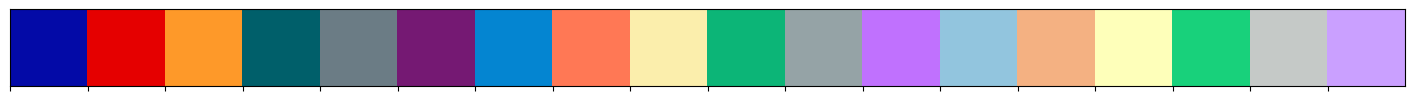

In [4]:
# palette = [ "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973", 
#             "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe", 
#             "#d1e5f0", "#fddbc7", "#ffffcb", "#12e193", "#d8dcd6", "#dfc5fe", 
#           ]
sns.palplot(sns.color_palette(palette[:18]))

In [5]:
from classificationBinaires import initDictionnaireClassificateurs, executionEssaiComparaisonClassificateurs,\
                                   affichageEvolutionMetriques, affichageROC, executeValidationCroisee, afficheSeparationsBinaires

In [6]:
from prjFormation import initProjet,affichageDonnees2d,affichageDonnees3d,createLinkageMatrix, afficheDendrogram,\
                         affichageDistribution,afficheColonneCible, add_median_labels, formatPct, createColumnsQualitatives

In [7]:
font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
sns.set(font_scale=2)

In [8]:
projet = initProjet(repertoireRacine='.',nomProjet='Maladie rénale chronique')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Démarche pour constituer un modèle de classification </div></b>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/demarche.png" width="800">

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>
>> >> **bp** - blood pressure<br>
>> >> **sg** - specific gravity<br>
>> >> **al** - albumin<br>
>> >> **su** - sugar<br>
>> >> **rbc** - red blood cells<br>
>> >> **bu** - blood urea<br>
>> >> **sc** - serum creatinine<br>
>> >> **sod** - sodium<br>
>> >> **pot** - potassium<br>
>> >> **hemo** - hemoglobin<br>
>> >> **wc** - white blood cell count<br>
>> >> **rc** - red blood cell count<br>
>> >> **htn** - hypertension<br>
>> >> **class** - class <br>

In [9]:
donnees = pd.read_csv('../donnees/Chronic kidney disease/new_model.csv')
donnees.columns = ['blood pressure',
                   'specific gravity',
                   'albumin',
                   'sugar',
                   'red blood cells',
                   'blood urea',
                   'serum creatinine',
                   'sodium',
                   'potassium',
                   'hemoglobin',
                   'white blood cell count',
                   'red blood cell count',
                   'hypertension',
                   'cible']

donnees.head()

,blood pressure,specific gravity,albumin,sugar,red blood cells,blood urea,serum creatinine,sodium,potassium,hemoglobin,white blood cell count,red blood cell count,hypertension,cible
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1


In [10]:
donnees.describe()

,blood pressure,specific gravity,albumin,sugar,red blood cells,blood urea,serum creatinine,sodium,potassium,hemoglobin,white blood cell count,red blood cell count,hypertension,cible
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,76.455000,1.017712,1.015000,0.395000,0.882500,57.40550,3.07235,137.529025,4.627850,12.526900,8406.090000,4.708275,0.369350,0.625000
std,13.476536,0.005434,1.272329,1.040038,0.322418,49.28597,5.61749,9.204273,2.819783,2.716171,2523.219976,0.840315,0.482023,0.484729
min,50.000000,1.005000,0.000000,0.000000,0.000000,1.50000,0.40000,4.500000,2.500000,3.100000,2200.000000,2.100000,0.000000,0.000000
25%,70.000000,1.015000,0.000000,0.000000,1.000000,27.00000,0.90000,135.000000,4.000000,10.875000,6975.000000,4.500000,0.000000,0.000000
50%,78.000000,1.020000,1.000000,0.000000,1.000000,44.00000,1.40000,137.530000,4.630000,12.530000,8406.000000,4.710000,0.000000,1.000000
75%,80.000000,1.020000,2.000000,0.000000,1.000000,61.75000,3.07000,141.000000,4.800000,14.625000,9400.000000,5.100000,1.000000,1.000000
max,180.000000,1.025000,5.000000,5.000000,1.000000,391.00000,76.00000,163.000000,47.000000,17.800000,26400.000000,8.000000,1.000000,1.000000


In [11]:
for col in donnees.columns:
    print(col,'\n\t',donnees[col].sort_values().unique())

blood pressure 
	 [ 50.  60.  70.  76.  80.  90. 100. 110. 120. 140. 180.]
specific gravity 
	 [1.005 1.01  1.015 1.02  1.025]
albumin 
	 [0. 1. 2. 3. 4. 5.]
sugar 
	 [0. 1. 2. 3. 4. 5.]
red blood cells 
	 [0. 1.]
blood urea 
	 [  1.5  10.   15.   16.   17.   18.   19.   20.   21.   22.   23.   24.
  25.   26.   27.   28.   29.   30.   31.   32.   33.   34.   35.   36.
  37.   38.   39.   40.   41.   42.   44.   45.   46.   47.   48.   49.
  50.   50.1  51.   52.   53.   54.   55.   56.   57.   58.   60.   61.
  64.   65.   66.   67.   68.   70.   71.   72.   73.   74.   75.   76.
  77.   79.   80.   82.   85.   86.   87.   88.   89.   90.   92.   93.
  94.   95.   96.   98.   98.6 103.  106.  107.  111.  113.  114.  115.
 118.  125.  132.  133.  137.  139.  142.  145.  146.  148.  150.  153.
 155.  158.  162.  163.  164.  165.  166.  176.  180.  186.  191.  202.
 208.  215.  217.  219.  223.  235.  241.  309.  322.  391. ]
serum creatinine 
	 [ 0.4   0.5   0.6   0.7   0.8   0.9   1.  

In [12]:
donnees.columns

Index(['blood pressure', 'specific gravity', 'albumin', 'sugar',
       'red blood cells', 'blood urea', 'serum creatinine', 'sodium',
       'potassium', 'hemoglobin', 'white blood cell count',
       'red blood cell count', 'hypertension', 'cible'],
      dtype='object')

In [13]:
quantitatives = ['blood pressure', 'specific gravity', 'blood urea', 'serum creatinine', 'sodium',
                 'potassium', 'hemoglobin', 'white blood cell count', 'red blood cell count', 'hypertension']

qualitatives = ['albumin', 'sugar','red blood cells']

In [14]:
donnees.isna().sum().sum()

0

>> <div style='padding:15px;color:#030aa7;background-color:#d8dcd6;font-size:120%;text-align: left;font-family: Georgia, serif'>Il n'y a pas de valeurs non renseignées</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Separation des données pour l'apprentissage</div></b>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/echantillonTraitementValidation.png" width="800">

<div style='padding:15px;color:#030aa7;font-size:120%;text-align: left'>L'échantillon validation <b>256</b> individus</div>

In [15]:
X = donnees.drop(columns='cible')
y = donnees['cible']
y.index = X.index

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Separation des données pour l'apprentissage</div></b>

<img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/classification/echantillonApprentissageTest.png" width="800">

<div style='padding:15px;color:#030aa7;font-size:120%;text-align: left'>L'échantillon validation <b>256</b> individus</div>

In [16]:
X_train, X_test, y_train, y_test = train_test_split( X, 
                                                     y, 
                                                     test_size=50, 
                                                     random_state=0, 
                                                     stratify = y
                                                   ) 
donnees.loc[X_train.index,'échantillon'] = 'apprentissage'
donnees.loc[X_test.index ,'échantillon'] = 'test'

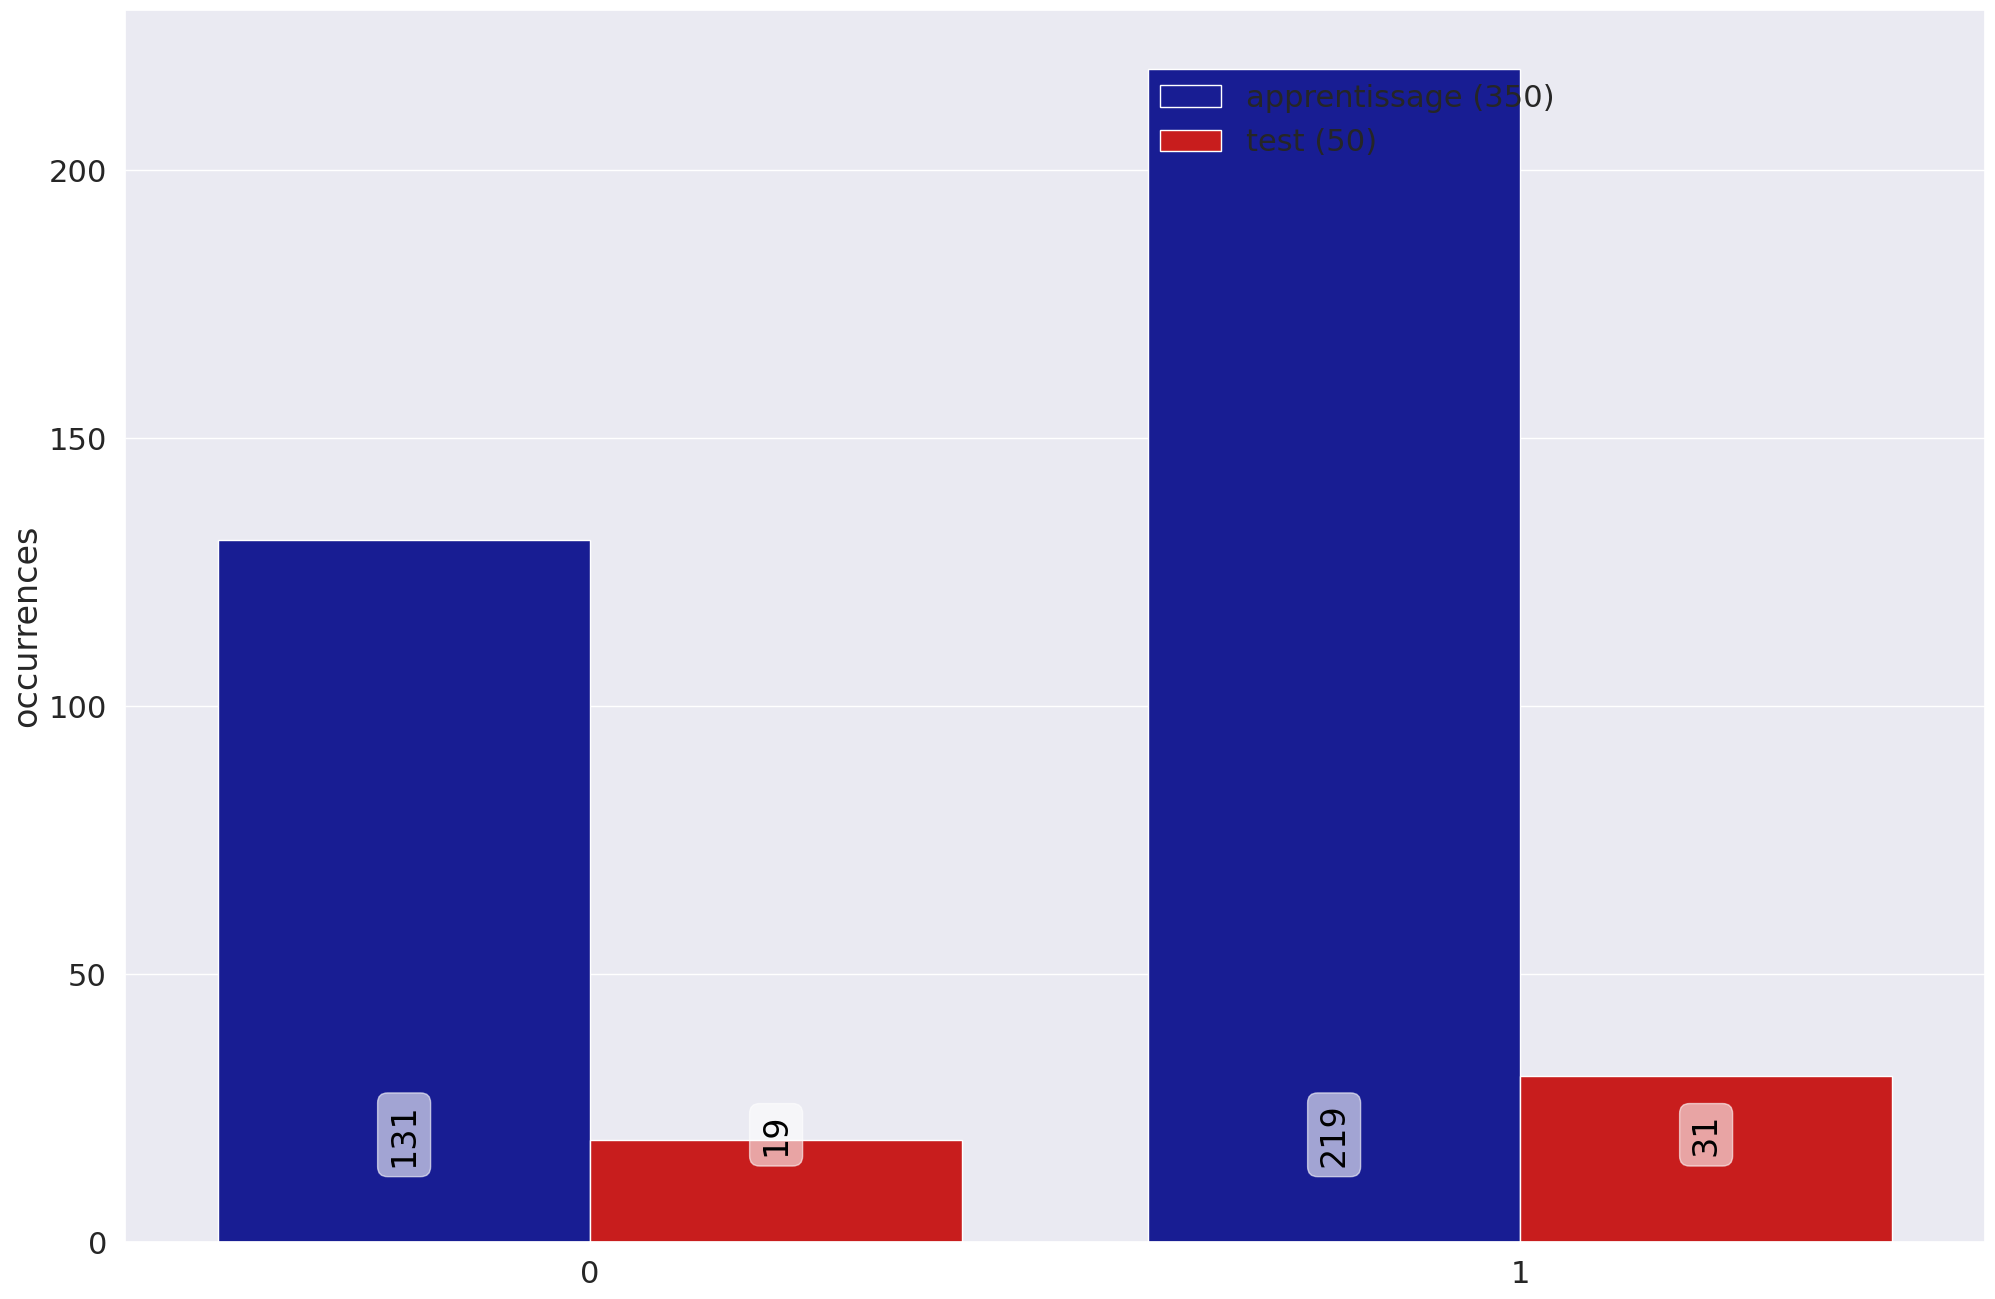

In [17]:
fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(24,16))
afficheSeparationsBinaires( donnees, palette, ax, cible='cible')

In [18]:
donnees.reset_index(drop=True,inplace=True)
donnees.set_index(['échantillon','cible'],inplace=True)
donnees.to_parquet(os.path.join(projet.repertoireDonnees,'donnees_echantillons.parquet'))

In [19]:
X = donnees.copy()
y = X.reset_index()['cible']
y.index = X.index

In [20]:
X_train, X_test, y_train, y_test = X.loc[('apprentissage'),:],\
                                   X.loc[('test'),:],\
                                   y.loc[('apprentissage')],\
                                   y.loc[('test')] 